# VNExpress News Data Overview

VNExpress là một trong những trang báo điện tử lớn tại Việt Nam. 
Trong project này, nhóm thu thập dữ liệu từ hai chuyên mục:

- Sức khỏe
- Giải trí

Nguồn dữ liệu:

https://vnexpress.net/suc-khoe  
https://vnexpress.net/giai-tri

Mục tiêu của notebook này:

- Hiểu cấu trúc dữ liệu đã crawl
- Phân tích dữ liệu thô (raw data)
- Tìm missing values
- Phát hiện vấn đề cần xử lý trước khi clean data

## 1. Import các thư viện cần thiết

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import re
from collections import Counter

sns.set(style="whitegrid")

pd.set_option('display.max_columns', None)

## 2. Đọc và tìm hiểu dữ liệu

### 2.1 Đọc dữ liệu từ file CSV

In [15]:
DATA_PATH = "../data/raw_data/"

df = pd.read_csv(DATA_PATH + "vnexpress_raw_data.csv", encoding="utf-8")

print("Kích thước dataset:", df.shape)

Kích thước dataset: (1182, 11)


### 2.2 Xem vài dòng dữ liệu đầu

In [16]:
df.head()

,title,description,date,category,thumbnail,content,author,tags,group,nums_of_comments,url
0,Mỹ nhân Thái cùng chồng con nghỉ dưỡng ở Nha T...,"Khánh HòaPokchat Thiamchai - sao Thái đóng ""Yê...","Thứ năm, 5/3/2026, 07:00 (GMT+7)",Giới sao,https://i1-giaitri.vnecdn.net/2026/03/04/dien-...,"Trên trang cá nhân ngày 3/3, người đẹp Pokchat...",Như Anh,pokchat thiamchai,Giải trí,0,https://vnexpress.net/bo-suu-tap-trang-suc-dun...
1,Mỹ nhân Thái cùng chồng con nghỉ dưỡng ở Nha T...,"Khánh HòaPokchat Thiamchai - sao Thái đóng ""Yê...","Thứ năm, 5/3/2026, 07:00 (GMT+7)",Giới sao,https://i1-giaitri.vnecdn.net/2026/03/04/dien-...,"Trên trang cá nhân ngày 3/3, người đẹp Pokchat...",Như Anh,pokchat thiamchai,Giải trí,0,https://vnexpress.net/nhung-thuc-pham-giau-kho...
2,Mỹ nhân Thái cùng chồng con nghỉ dưỡng ở Nha T...,"Khánh HòaPokchat Thiamchai - sao Thái đóng ""Yê...","Thứ năm, 5/3/2026, 07:00 (GMT+7)",Giới sao,https://i1-giaitri.vnecdn.net/2026/03/04/dien-...,"Trên trang cá nhân ngày 3/3, người đẹp Pokchat...",Như Anh,pokchat thiamchai,Giải trí,0,https://vnexpress.net/5-bai-tap-don-gian-co-th...
3,Mỹ nhân Thái cùng chồng con nghỉ dưỡng ở Nha T...,"Khánh HòaPokchat Thiamchai - sao Thái đóng ""Yê...","Thứ năm, 5/3/2026, 07:00 (GMT+7)",Giới sao,https://i1-giaitri.vnecdn.net/2026/03/04/dien-...,"Trên trang cá nhân ngày 3/3, người đẹp Pokchat...",Như Anh,pokchat thiamchai,Giải trí,0,https://vnexpress.net/uong-nuoc-cot-chanh-co-g...
4,Mỹ nhân Thái cùng chồng con nghỉ dưỡng ở Nha T...,"Khánh HòaPokchat Thiamchai - sao Thái đóng ""Yê...","Thứ năm, 5/3/2026, 07:00 (GMT+7)",Giới sao,https://i1-giaitri.vnecdn.net/2026/03/04/dien-...,"Trên trang cá nhân ngày 3/3, người đẹp Pokchat...",Như Anh,pokchat thiamchai,Giải trí,0,https://vnexpress.net/my-nhan-thai-cung-chong-...


### 2.3 Thông tin các cột dữ liệu

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1182 entries, 0 to 1181
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   title             1182 non-null   str  
 1   description       1181 non-null   str  
 2   date              1182 non-null   str  
 3   category          1182 non-null   str  
 4   thumbnail         1098 non-null   str  
 5   content           1182 non-null   str  
 6   author            1182 non-null   str  
 7   tags              1181 non-null   str  
 8   group             1182 non-null   str  
 9   nums_of_comments  1182 non-null   int64
 10  url               1182 non-null   str  
dtypes: int64(1), str(10)
memory usage: 101.7 KB


### 2.4 Kiểm tra dữ liệu thiếu

In [18]:
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing (%)": missing_percentage
})

missing_df.sort_values(by="Missing Values", ascending=False)

,Missing Values,Missing (%)
thumbnail,84,7.106599
description,1,0.084602
tags,1,0.084602
title,0,0.000000
date,0,0.000000
category,0,0.000000
content,0,0.000000
author,0,0.000000
group,0,0.000000
nums_of_comments,0,0.000000


### 2.5 Thống kê mô tả

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
nums_of_comments,1182.0,0.351946,2.085714,0.0,0.0,0.0,0.0,29.0


## 3. Phân bố dữ liệu

### 3.1 Số lượng bài viết theo nhóm

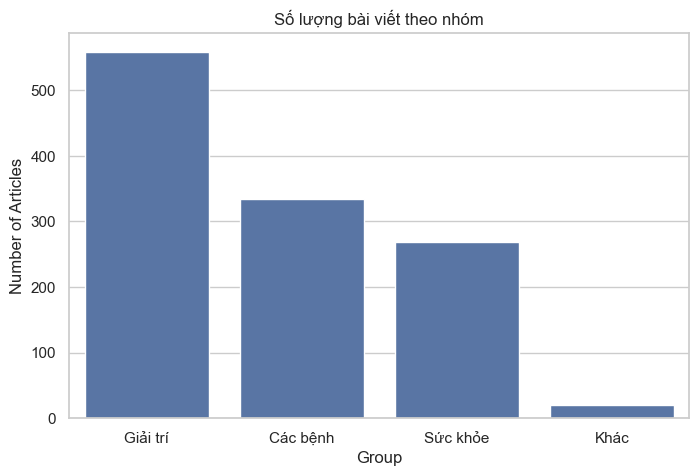

In [20]:
plt.figure(figsize=(8,5))

group_counts = df["group"].value_counts()

sns.barplot(
    x=group_counts.index,
    y=group_counts.values
)

plt.title("Số lượng bài viết theo nhóm")
plt.xlabel("Group")
plt.ylabel("Number of Articles")

plt.show()

### 3.2 Số lượng bài theo category

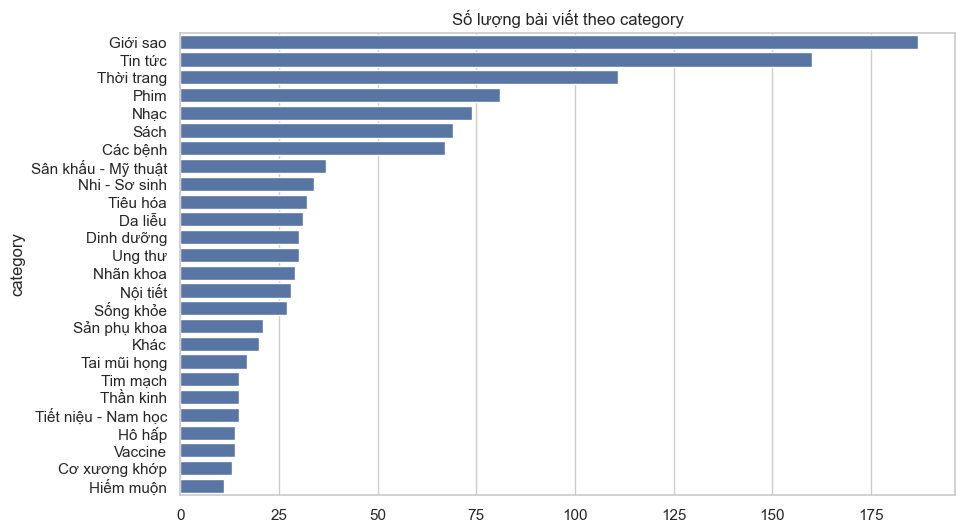

In [21]:
plt.figure(figsize=(10,6))

category_counts = df["category"].value_counts()

sns.barplot(
    y=category_counts.index,
    x=category_counts.values
)

plt.title("Số lượng bài viết theo category")

plt.show()

### 3.3 Phân bố số lượng bình luận

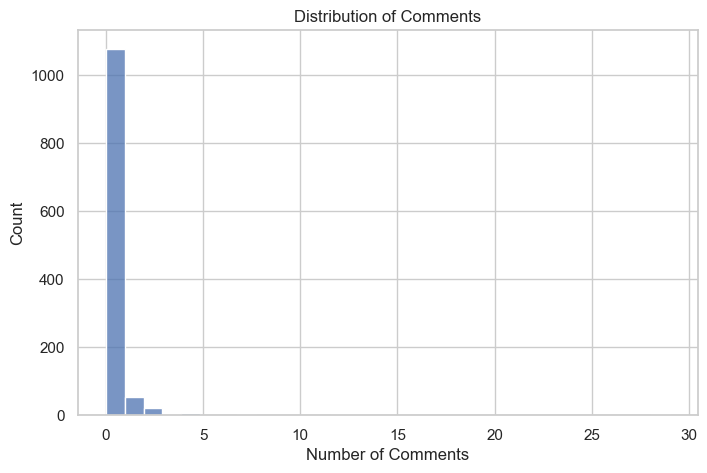

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df["nums_of_comments"], bins=30)

plt.title("Distribution of Comments")

plt.xlabel("Number of Comments")

plt.show()

### 3.4 Phân tích độ dài title và content

In [23]:
df["title_length"] = df["title"].astype(str).apply(lambda x: len(x.split()))
df["content_length"] = df["content"].astype(str).apply(lambda x: len(x.split()))

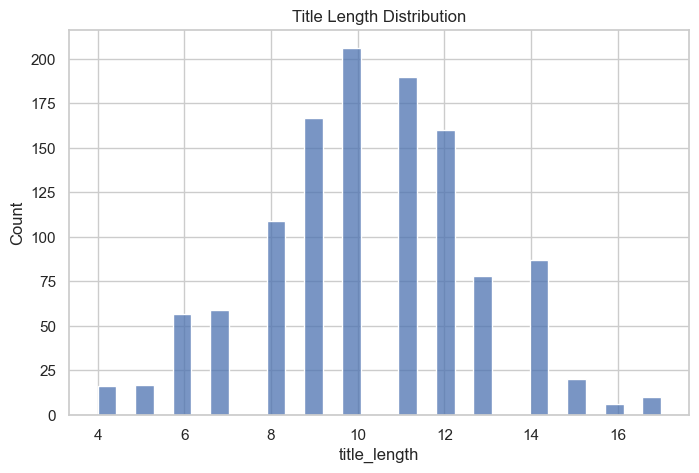

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df["title_length"], bins=30)

plt.title("Title Length Distribution")

plt.show()

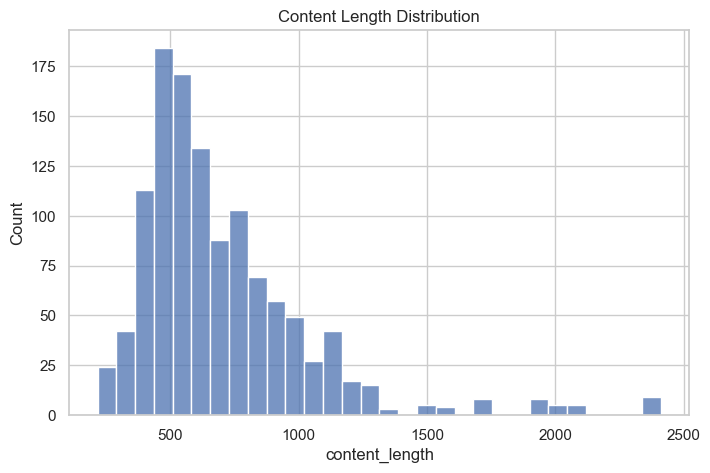

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df["content_length"], bins=30)

plt.title("Content Length Distribution")

plt.show()

### 3.5 Kiểm tra bài viết bất thường

In [26]:
df.sort_values("content_length", ascending=False).head()

,title,description,date,category,thumbnail,content,author,tags,group,nums_of_comments,url,title_length,content_length
571,Mối tình 'khắc cốt ghi tâm' của cặp sao Hàn,Jin Tae Hyun ví mối tình của anh với bà xã Par...,"Thứ ba, 24/2/2026, 20:30 (GMT+7)",Giới sao,https://i1-giaitri.vnecdn.net/2026/02/24/Jin-T...,"Trên trang cá nhân, vợ chồngJin Tae Hyun - Par...",Như Anh,"jin tae hyun, park si eun, hãy nắm tay anh",Giải trí,0,https://vnexpress.net/moi-tinh-khac-cot-ghi-ta...,10,2412
567,Mối tình 'khắc cốt ghi tâm' của cặp sao Hàn,Jin Tae Hyun ví mối tình của anh với bà xã Par...,"Thứ ba, 24/2/2026, 20:30 (GMT+7)",Giới sao,https://i1-giaitri.vnecdn.net/2026/02/24/Jin-T...,"Trên trang cá nhân, vợ chồngJin Tae Hyun - Par...",Như Anh,"jin tae hyun, park si eun, hãy nắm tay anh",Giải trí,0,https://vnexpress.net/tai-tu-ha-jung-woo-cong-...,10,2412
568,Mối tình 'khắc cốt ghi tâm' của cặp sao Hàn,Jin Tae Hyun ví mối tình của anh với bà xã Par...,"Thứ ba, 24/2/2026, 20:30 (GMT+7)",Giới sao,https://i1-giaitri.vnecdn.net/2026/02/24/Jin-T...,"Trên trang cá nhân, vợ chồngJin Tae Hyun - Par...",Như Anh,"jin tae hyun, park si eun, hãy nắm tay anh",Giải trí,0,https://vnexpress.net/loat-phim-harry-potter-k...,10,2412
569,Mối tình 'khắc cốt ghi tâm' của cặp sao Hàn,Jin Tae Hyun ví mối tình của anh với bà xã Par...,"Thứ ba, 24/2/2026, 20:30 (GMT+7)",Giới sao,https://i1-giaitri.vnecdn.net/2026/02/24/Jin-T...,"Trên trang cá nhân, vợ chồngJin Tae Hyun - Par...",Như Anh,"jin tae hyun, park si eun, hãy nắm tay anh",Giải trí,0,https://vnexpress.net/hon-330-ca-cap-cuu-do-ph...,10,2412
570,Mối tình 'khắc cốt ghi tâm' của cặp sao Hàn,Jin Tae Hyun ví mối tình của anh với bà xã Par...,"Thứ ba, 24/2/2026, 20:30 (GMT+7)",Giới sao,https://i1-giaitri.vnecdn.net/2026/02/24/Jin-T...,"Trên trang cá nhân, vợ chồngJin Tae Hyun - Par...",Như Anh,"jin tae hyun, park si eun, hãy nắm tay anh",Giải trí,0,https://vnexpress.net/ho-dom-mau-gi-set-co-pha...,10,2412


## 4. Nhận xét về dữ liệu raw

Qua quá trình phân tích dữ liệu thô:

- Dataset gồm các bài viết từ hai chuyên mục:
  - Sức khỏe
  - Giải trí

- Một số vấn đề phát hiện:
  - Có thể tồn tại dữ liệu thiếu
  - Định dạng ngày chưa chuẩn
  - Văn bản chưa được chuẩn hóa
  - Có thể có bài trùng lặp

→ Vì vậy cần bước **data cleaning** để:

- Loại bỏ duplicates
- Chuẩn hóa text
- Chuẩn hóa date
- Xử lý missing values

## 5. Định hướng bài toán

Từ dữ liệu này có thể xây dựng các bài toán:

### Hướng 1: Dự đoán số lượng bình luận
- Input: title_length, content_length, category...
- Output: nums_of_comments

### Hướng 2: Phân loại bài viết
- Phân loại bài viết thuộc nhóm:
  - Sức khỏe
  - Giải trí

### Hướng 3: Phân tích xu hướng nội dung
- Phân tích chủ đề phổ biến
- Phân tích độ dài bài viết